# Exploratory Data Analysis (EDA) — InHARD

**Industrial Human Action Recognition Dataset** (LINEACT-CESI / IEEE ICHMS 2020).

This notebook is a **template for deep EDA** on the tabular index shipped with InHARD (`InHARD.csv`). It complements the narrative and layout description in:

`data_sample/InHARD-master/analysis.md`

**Scope here:** annotations, timings, subjects, operations, and class distributions. **Out of scope:** loading raw MP4/BVH streams (add separate media EDA if needed).

---


## 1. Setup & environment

Standard scientific stack plus **Plotly** for interactive charts. Global plotting style keeps figures publication-ready.


In [4]:
# --- Imports ---
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display  # explicit for non-Jupyter runners / clarity

import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is optional: notebook runs with Matplotlib/Seaborn only if plotly is not installed.
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    px.defaults.template = "plotly_white"
    USE_PLOTLY = True
except ModuleNotFoundError:
    px = go = make_subplots = None  # type: ignore[assignment,misc]
    USE_PLOTLY = False

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Global plotting configuration ---
# Prefer modern Matplotlib seaborn theme; fall back for older Matplotlib builds.
for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["image.cmap"] = "viridis"

# Plotly: default template (readable in light UI)
px.defaults.template = "plotly_white"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Paths & data loading

We resolve the project root by locating `data_sample/InHARD-master`, so the notebook works whether the kernel **current working directory** is the repo root or this folder.

**Primary table:** `01-InHARD/Segmented/InHARD.csv` — one row per clip (includes **No action**). Optionally load **Online** index for comparison (no background rows in plain `Online/InHARD.csv`).


In [5]:
def resolve_inhard_root(start: Path | None = None) -> Path:
    """Walk parents from cwd or start until data_sample/InHARD-master exists."""
    start = start or Path.cwd().resolve()
    for directory in [start, *start.parents]:
        candidate = directory / "data_sample" / "InHARD-master"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find data_sample/InHARD-master. "
        "Open the notebook from the repository or set INHARD_ROOT manually."
    )


INHARD_ROOT = resolve_inhard_root()
SEGMENTED_CSV = INHARD_ROOT / "01-InHARD" / "Segmented" / "InHARD.csv"
ONLINE_CSV = INHARD_ROOT / "01-InHARD" / "Online" / "InHARD.csv"
ANALYSIS_DOC = INHARD_ROOT / "analysis.md"

print("INHARD_ROOT:", INHARD_ROOT)
print("Segmented CSV exists:", SEGMENTED_CSV.is_file())


def load_inhard_index(path: Path) -> pd.DataFrame:
    """Load InHARD index; normalize unnamed export column if present."""
    frame = pd.read_csv(path)
    # Segmented export often has an empty column name for row index
    if "" in frame.columns:
        frame = frame.rename(columns={"": "export_row_index"})
    return frame


df = load_inhard_index(SEGMENTED_CSV)

# Optional: full-session index (no Meta_action class 0 in this file)
df_online = load_inhard_index(ONLINE_CSV) if ONLINE_CSV.is_file() else None

print(f"Segmented rows: {len(df):,} | columns: {list(df.columns)}")


INHARD_ROOT: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/data_sample/InHARD-master
Segmented CSV exists: True
Segmented rows: 5,303 | columns: ['Unnamed: 0', 'Action_end_bvh_frame', 'Action_end_rgb_frame', 'Action_end_rgb_sec', 'Action_label', 'Action_start_bvh_frame', 'Action_start_rgb_frame', 'Action_start_rgb_sec', 'Duration_sec', 'File', 'Meta_action_class_number', 'Meta_action_label', 'Operation', 'Recurrence', 'Subject']


## 3. Data loading & initial audit

Quick structural view: shape, preview, dtypes, and numeric summaries.


In [6]:
# --- Shape & preview ---
print("SHAPE:", df.shape)
display(df.head(10))


SHAPE: (5303, 15)


,Unnamed: 0,Action_end_bvh_frame,Action_end_rgb_frame,Action_end_rgb_sec,Action_label,Action_start_bvh_frame,Action_start_rgb_frame,Action_start_rgb_sec,Duration_sec,File,Meta_action_class_number,Meta_action_label,Operation,Recurrence,Subject
0,0,1071,270,9.00,[OP010] Consult sheets,324,82,2.72,6.28,P01_R01,2,Consult sheets,OP010,R01,P01
1,1,1528,385,12.84,[OP010] Catch Fixture key LARD,1343,338,11.28,1.56,P01_R01,7,Picking left,OP010,R01,P01
2,2,2247,566,18.88,[OP010] Place LARD on Profile P360-1,1647,415,13.84,5.04,P01_R01,12,Assemble system,OP010,R01,P01
3,3,3028,762,25.44,[OP010] Catch Fixation FIXA1,2776,699,23.32,2.12,P01_R01,6,Picking in front,OP010,R01,P01
4,4,3428,863,28.80,[OP010] Place FIXA1 on LARD at 160mm,3152,794,26.48,2.32,P01_R01,12,Assemble system,OP010,R01,P01
5,5,3857,971,32.40,[OP010] Catch Bolt B820,3719,936,31.24,1.16,P01_R01,7,Picking left,OP010,R01,P01
6,6,4514,1136,37.92,[OP010] Take measuring rod,4352,1096,36.56,1.36,P01_R01,8,Take measuring rod,OP010,R01,P01
7,7,4809,1211,40.40,[OP010] Take screwdriver,4685,1180,39.36,1.04,P01_R01,4,Take screwdriver,OP010,R01,P01
8,8,5304,1335,44.56,[OP010] Screw FIXA1 with B820,4904,1235,41.20,3.36,P01_R01,12,Assemble system,OP010,R01,P01
9,9,5623,1416,47.24,[OP010] Put down screwdriver,5328,1341,44.76,2.48,P01_R01,5,Put down screwdriver,OP010,R01,P01


In [7]:
# --- Schema (non-null counts, dtypes) ---
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5303 entries, 0 to 5302
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                5303 non-null   int64  
 1   Action_end_bvh_frame      5303 non-null   int64  
 2   Action_end_rgb_frame      5303 non-null   int64  
 3   Action_end_rgb_sec        5303 non-null   float64
 4   Action_label              5303 non-null   object 
 5   Action_start_bvh_frame    5303 non-null   int64  
 6   Action_start_rgb_frame    5303 non-null   int64  
 7   Action_start_rgb_sec      5303 non-null   float64
 8   Duration_sec              5303 non-null   float64
 9   File                      5303 non-null   object 
 10  Meta_action_class_number  5303 non-null   int64  
 11  Meta_action_label         5303 non-null   object 
 12  Operation                 5303 non-null   object 
 13  Recurrence                5303 non-null   object 
 14  Subject 

In [8]:
# --- Numeric summaries ---
# describe() includes only numeric columns; useful for frame indices and durations
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5303.0,2380.876296,1397.183952,0.00,1164.00,2360.00,3599.500000,4802.00
Action_end_bvh_frame,5303.0,26121.089006,18204.994487,252.00,11335.00,23696.00,37390.500000,104697.00
Action_end_rgb_frame,5303.0,6577.231378,4583.683270,64.00,2854.50,5968.00,9413.000000,26354.00
Action_end_rgb_sec,5303.0,219.460592,152.942317,2.12,95.24,199.12,314.079995,879.36
Action_start_bvh_frame,5303.0,25833.565529,18175.053228,29.00,11035.00,23397.00,37024.000000,103163.00
Action_start_rgb_frame,5303.0,6504.838205,4576.144748,7.00,2778.00,5891.00,9329.000000,25968.00
Action_start_rgb_sec,5303.0,217.044850,152.690887,0.24,92.70,196.56,311.280005,866.48
Duration_sec,5303.0,2.415742,1.768832,0.12,1.40,2.00,2.920000,26.96
Meta_action_class_number,5303.0,7.618141,4.022329,0.00,5.00,7.00,12.000000,14.00


## 4. Data integrity check

We verify **missing values**, **duplicate annotation rows**, and **dtype consistency** (e.g. IDs stored as strings, frame counts as integers).


In [9]:
# --- Missing values (counts and %) ---
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
integrity = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
integrity = integrity[integrity["missing_count"] > 0]
print("Columns with any missing values:")
display(integrity if len(integrity) else "None — no NaNs detected.")

# --- Full-row duplicates ---
# Exclude export_row_index if present — it is often unique per row
dup_subset = [c for c in df.columns if c != "export_row_index"]
dup_mask = df.duplicated(subset=dup_subset, keep=False)
n_dup_groups = df[dup_mask].drop_duplicates(subset=dup_subset).shape[0]
print(f"Duplicate rows (same values on {dup_subset}): {dup_mask.sum()}")

# --- Dtype sanity: columns that should be numeric ---
expected_numeric = [
    "Action_end_bvh_frame",
    "Action_end_rgb_frame",
    "Action_start_bvh_frame",
    "Action_start_rgb_frame",
    "Meta_action_class_number",
    "Duration_sec",
    "Action_end_rgb_sec",
    "Action_start_rgb_sec",
]
for col in expected_numeric:
    if col not in df.columns:
        continue
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"WARNING: {col!r} is not numeric (dtype={df[col].dtype}) — consider pd.to_numeric.")

# Coerce stable numeric types for downstream analysis
for col in expected_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Post-coercion dtypes (selected):")
print(df[ [c for c in expected_numeric if c in df.columns] ].dtypes)


Columns with any missing values:


'None — no NaNs detected.'

Duplicate rows (same values on ['Unnamed: 0', 'Action_end_bvh_frame', 'Action_end_rgb_frame', 'Action_end_rgb_sec', 'Action_label', 'Action_start_bvh_frame', 'Action_start_rgb_frame', 'Action_start_rgb_sec', 'Duration_sec', 'File', 'Meta_action_class_number', 'Meta_action_label', 'Operation', 'Recurrence', 'Subject']): 0
Post-coercion dtypes (selected):
Action_end_bvh_frame          int64
Action_end_rgb_frame          int64
Action_start_bvh_frame        int64
Action_start_rgb_frame        int64
Meta_action_class_number      int64
Duration_sec                float64
Action_end_rgb_sec          float64
Action_start_rgb_sec        float64
dtype: object


## 5. Univariate analysis

**Numerical:** histograms and boxplots for durations and frame spans (automation loop).

**Categorical:** frequency tables and bar charts for session, subject, operation, and labels.


In [10]:
# --- Identify column roles ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude pure index-like columns from distribution plots if desired
exclude_from_univariate = {"export_row_index"} if "export_row_index" in df.columns else set()
plot_numeric = [c for c in numeric_cols if c not in exclude_from_univariate]

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
# Treat low-cardinality integers (e.g. class id) as categorical for counts
if "Meta_action_class_number" in df.columns:
    categorical_cols = list(dict.fromkeys(categorical_cols + ["Meta_action_class_number"]))

print("Numeric columns for EDA:", plot_numeric)
print("Categorical columns for EDA:", categorical_cols)


Numeric columns for EDA: ['Unnamed: 0', 'Action_end_bvh_frame', 'Action_end_rgb_frame', 'Action_end_rgb_sec', 'Action_start_bvh_frame', 'Action_start_rgb_frame', 'Action_start_rgb_sec', 'Duration_sec', 'Meta_action_class_number']
Categorical columns for EDA: ['Action_label', 'File', 'Meta_action_label', 'Operation', 'Recurrence', 'Subject', 'Meta_action_class_number']


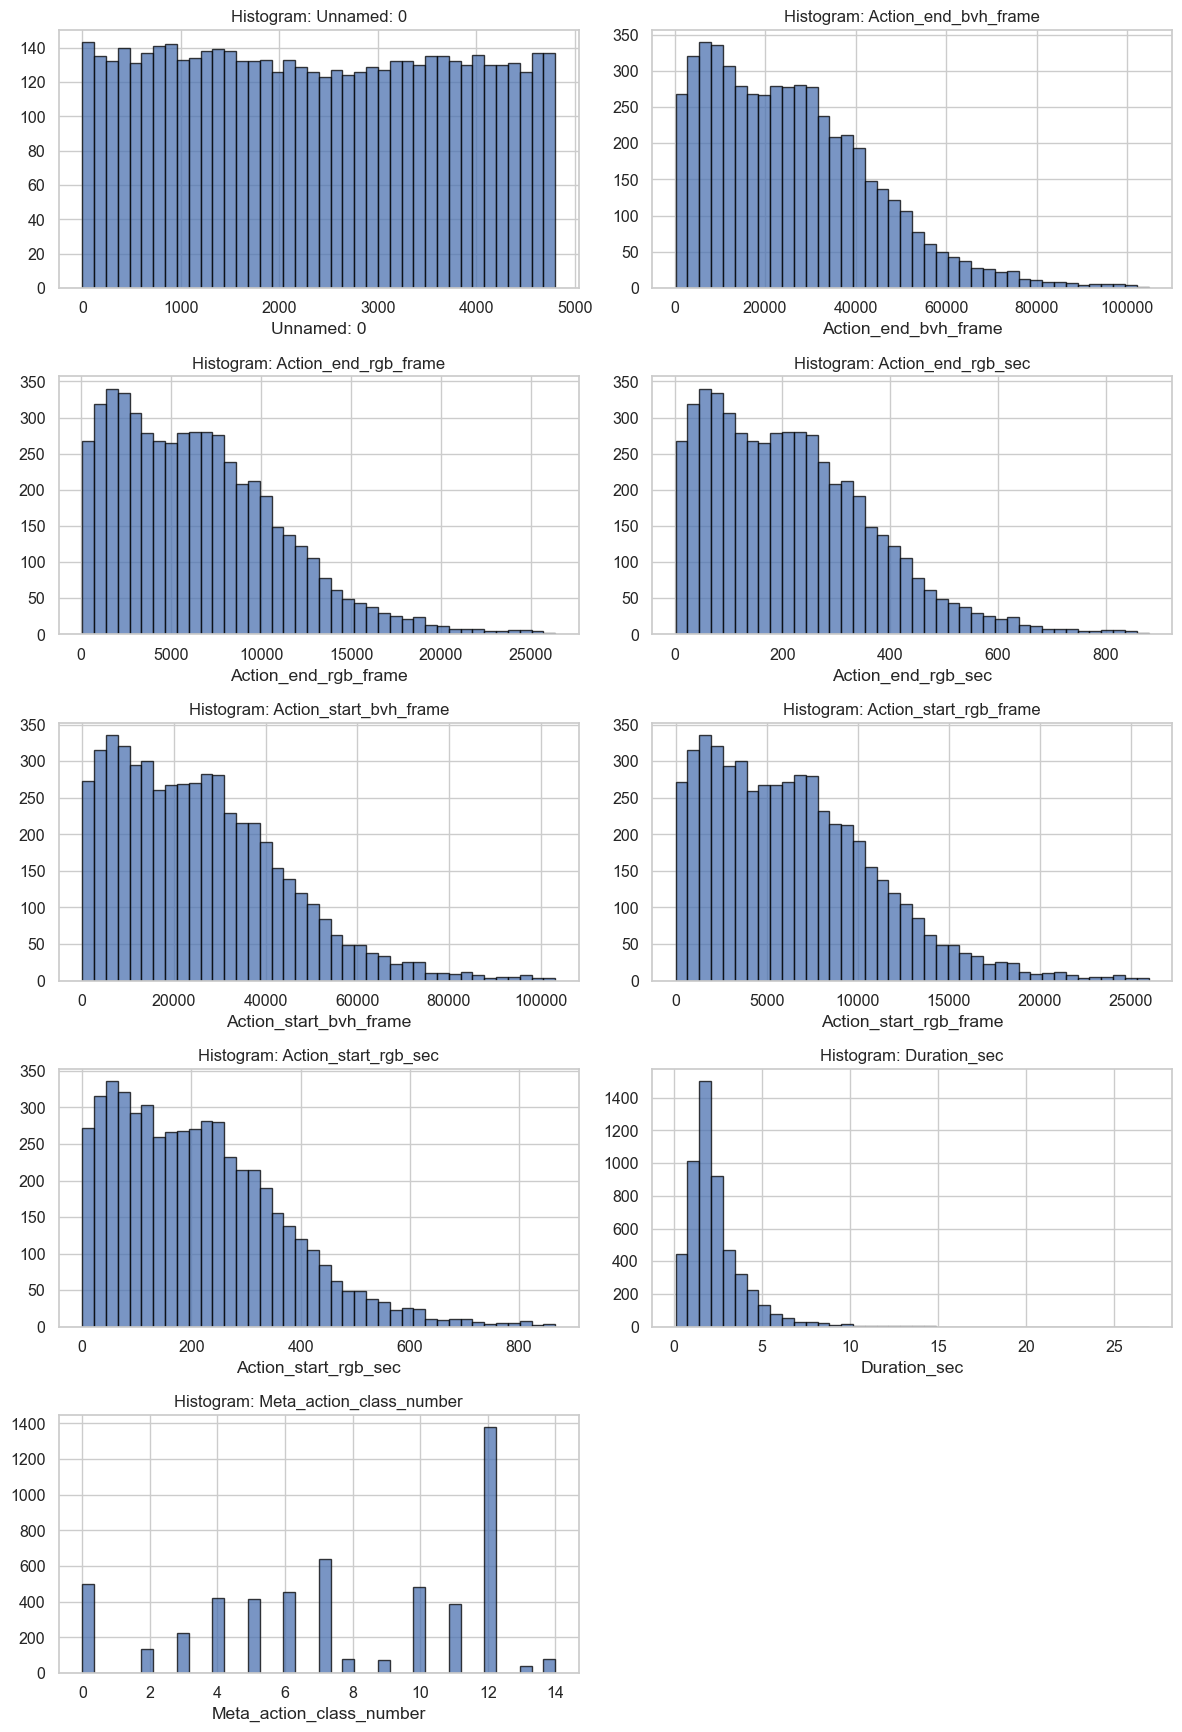

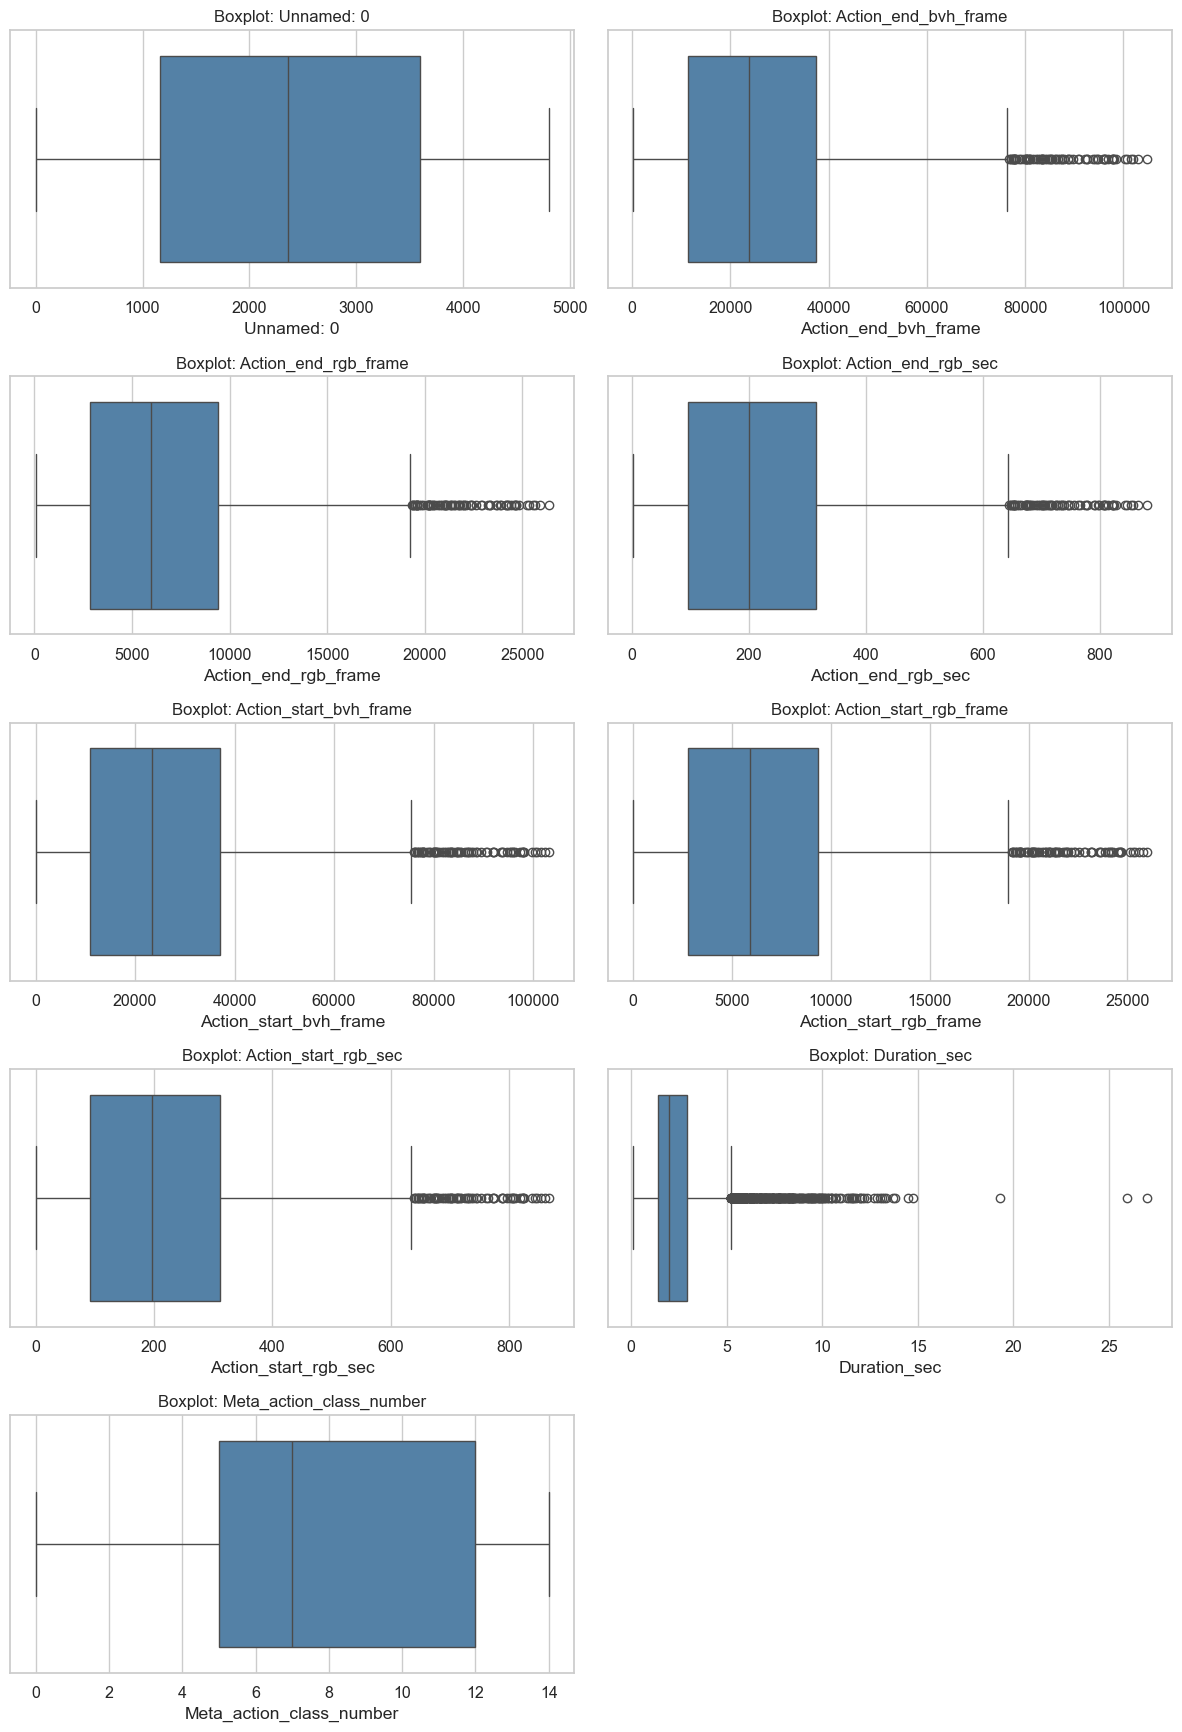

In [11]:
# --- Histograms + boxplots (numeric loop) ---
n_num = len(plot_numeric)
if n_num == 0:
    print("No numeric columns to plot.")
else:
    cols_per_row = 2
    n_rows = int(np.ceil(n_num / cols_per_row))
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(12, 3.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, plot_numeric):
        series = df[col].dropna()
        ax.hist(series, bins=min(40, max(10, int(np.sqrt(len(series))))), edgecolor="black", alpha=0.75)
        ax.set_title(f"Histogram: {col}")
        ax.set_xlabel(col)
    for j in range(len(plot_numeric), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(12, 3.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, plot_numeric):
        sns.boxplot(x=df[col], ax=ax, color="steelblue")
        ax.set_title(f"Boxplot: {col}")
    for j in range(len(plot_numeric), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


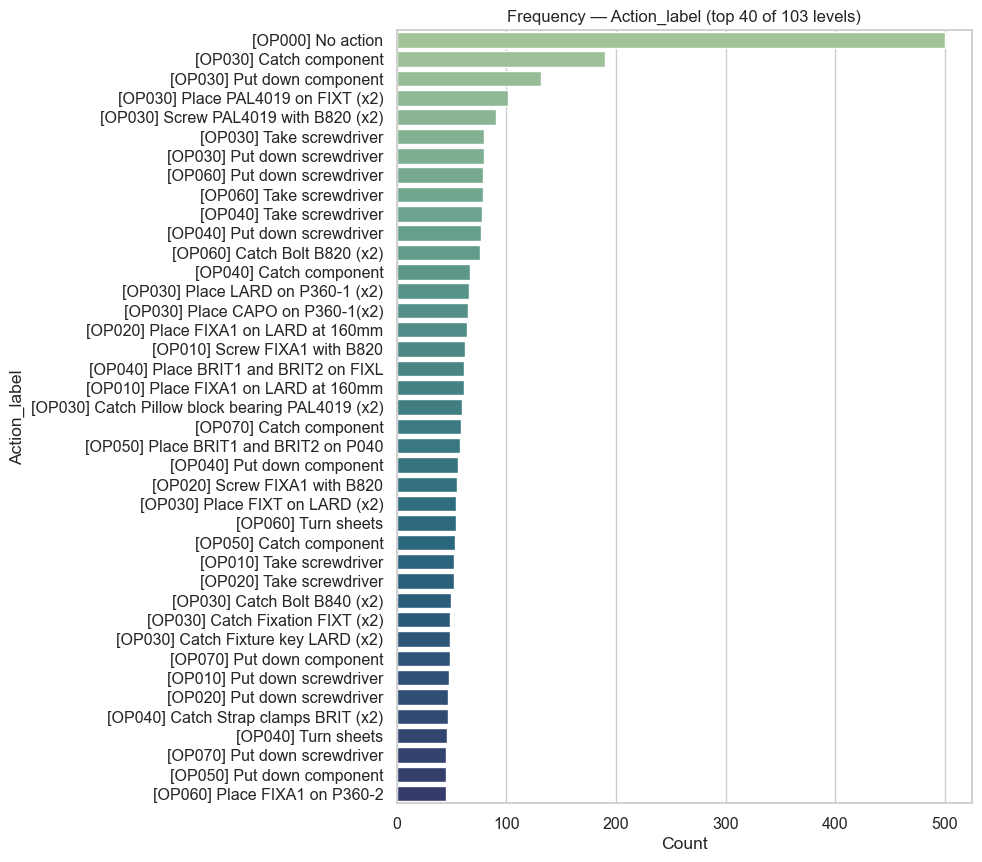

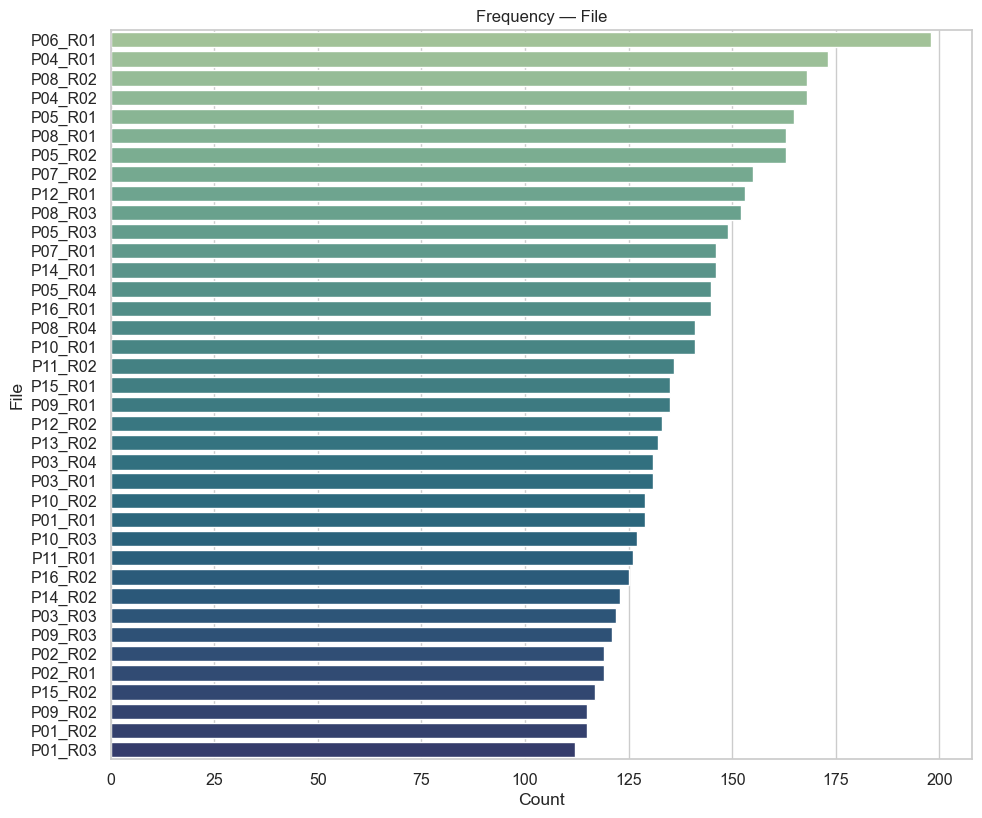

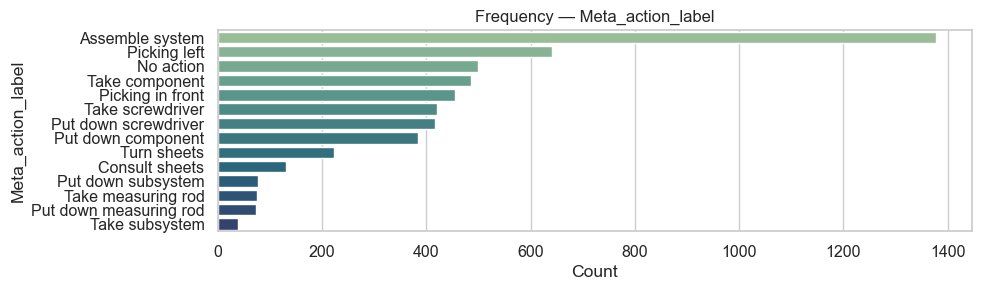

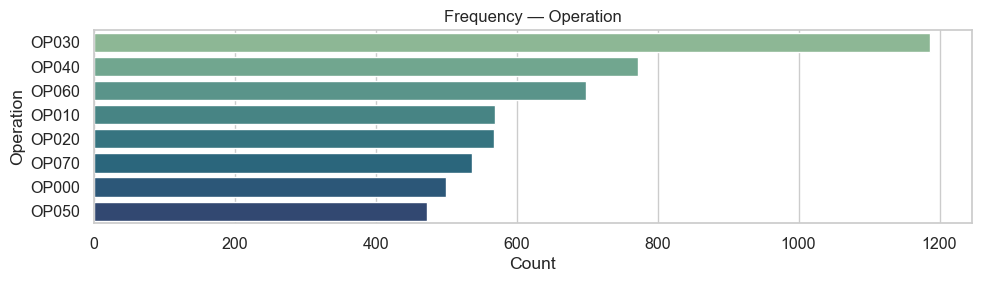

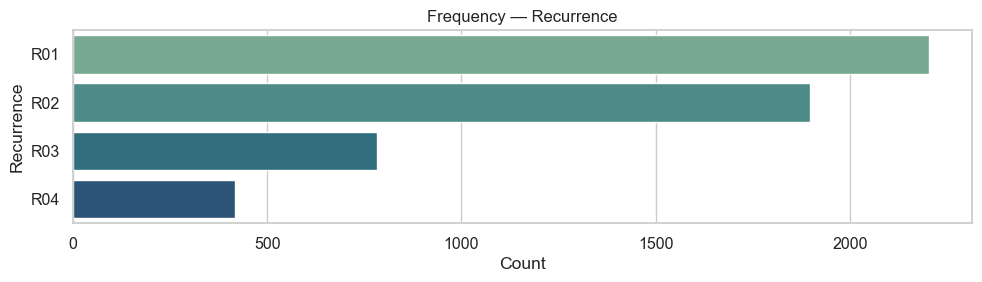

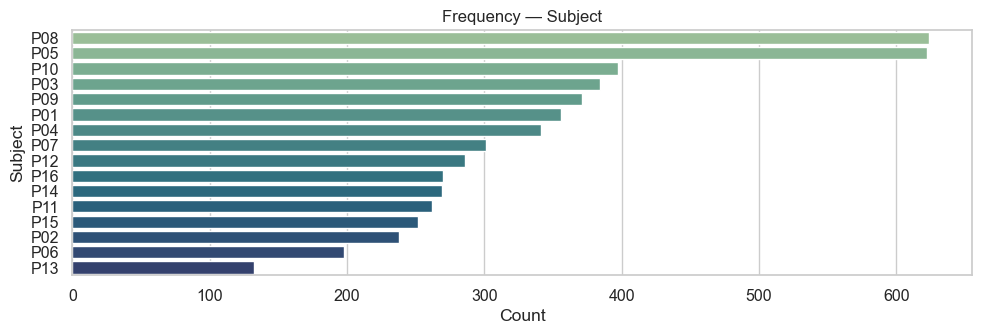

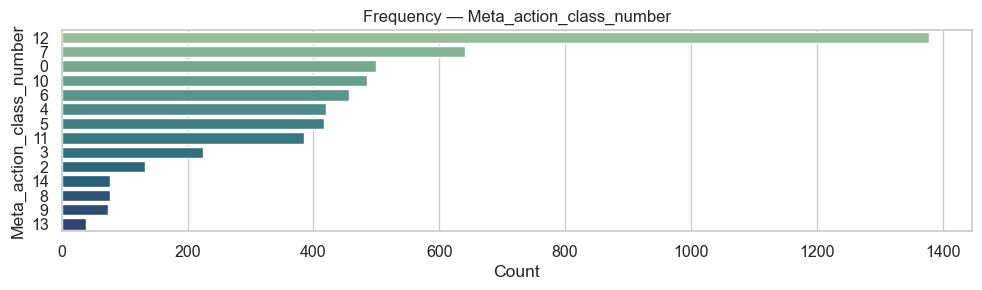

In [12]:
# --- Categorical frequency (loop) ---
max_levels = 40  # skip extremely high-cardinality raw Action_label in bar chart; still show top-N

for col in categorical_cols:
    vc = df[col].astype(str).value_counts()
    if len(vc) > max_levels:
        vc_plot = vc.head(max_levels)
        title_suffix = f" (top {max_levels} of {len(vc)} levels)"
    else:
        vc_plot = vc
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, max(3, 0.22 * len(vc_plot))))
    sns.barplot(x=vc_plot.values, y=vc_plot.index, ax=ax, hue=vc_plot.index, palette="crest", legend=False)
    ax.set_title(f"Frequency — {col}{title_suffix}")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()


In [13]:
# --- Interactive: meta-action counts (Plotly) ---
if "Meta_action_label" in df.columns:
    counts = df["Meta_action_label"].value_counts().reset_index()
    counts.columns = ["Meta_action_label", "count"]
    fig = px.bar(
        counts,
        x="count",
        y="Meta_action_label",
        orientation="h",
        title="Clips per meta-action (Segmented index)",
        text="count",
    )
    fig.update_layout(yaxis={"categoryorder": "total ascending"})
    fig.show()


## 6. Bivariate & multivariate analysis

- **Correlation heatmap** on numeric features (interpret with care: mixed scales).
- **Pairplot** on a **small numeric subset** (runtime-friendly).
- **Scatter** vs a configurable **target** (default: `Duration_sec`).

Set `TARGET_COL` to another numeric column if you want a different regression-style view.


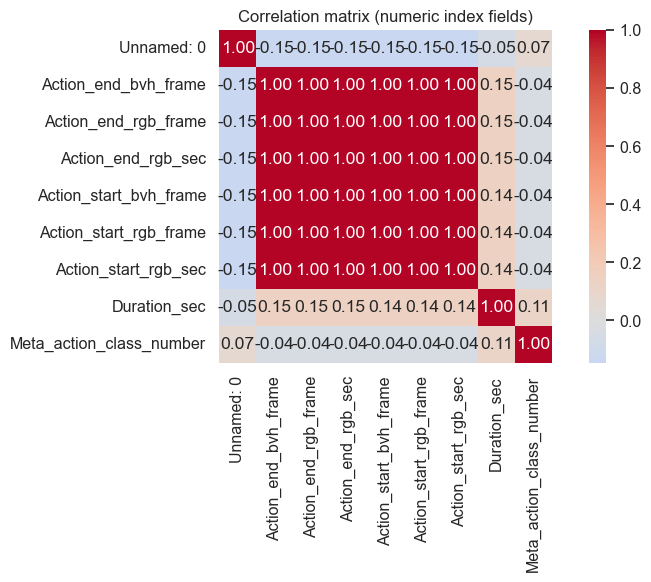

In [14]:
# --- Target for scatter / correlation views ---
TARGET_COL = "Duration_sec"  # change e.g. to Action_end_rgb_frame - Action_start_rgb_frame if derived

if TARGET_COL not in df.columns:
    raise KeyError(f"{TARGET_COL} not in dataframe — pick an existing numeric column.")

corr_cols = [c for c in plot_numeric if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols) * 0.6)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlation matrix (numeric index fields)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a correlation heatmap.")


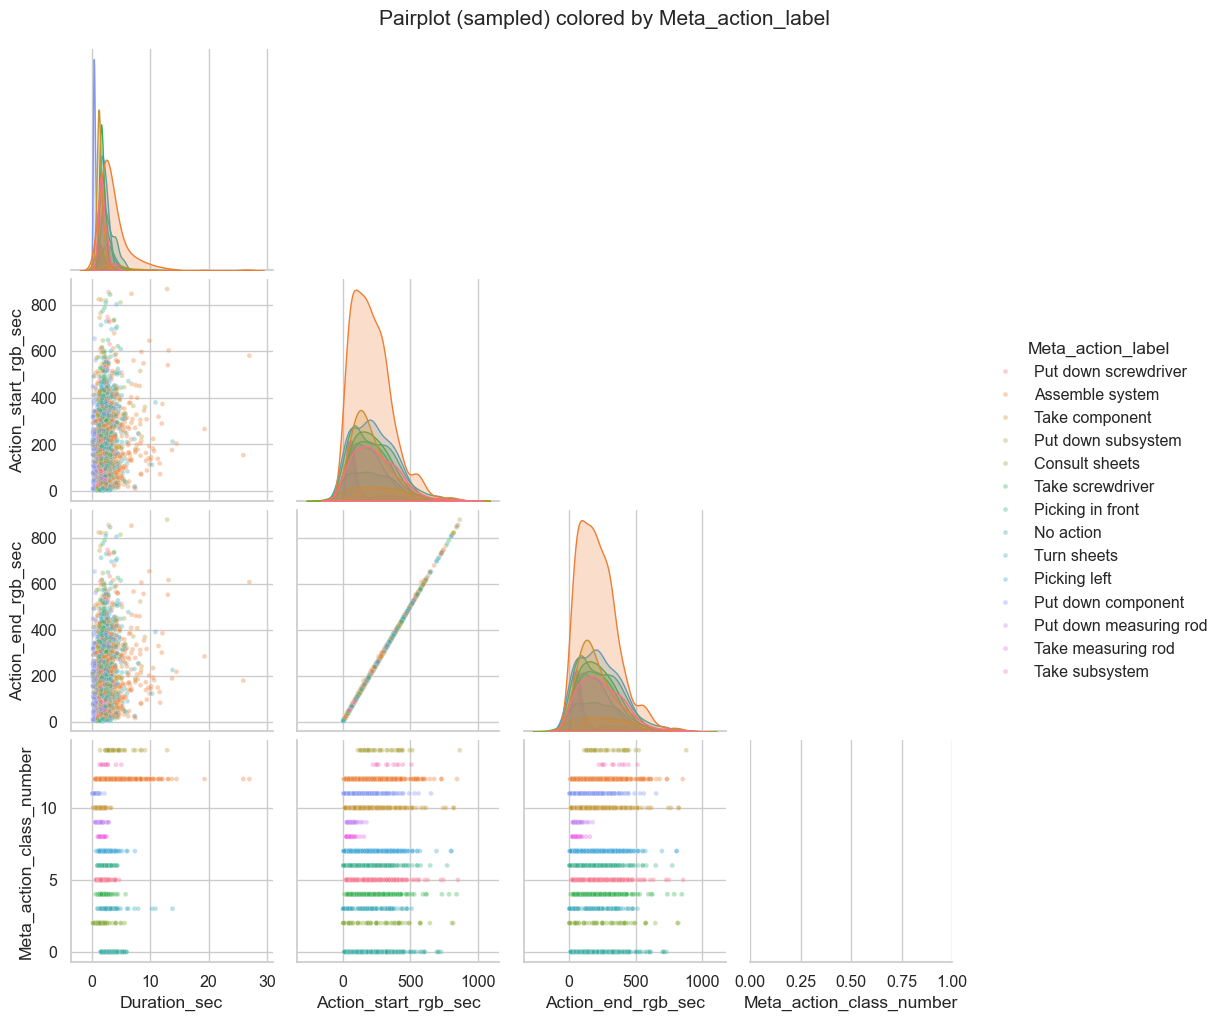

In [15]:
# --- Pairplot on a compact numeric subset ---
pair_cols = [c for c in [
    "Duration_sec",
    "Action_start_rgb_sec",
    "Action_end_rgb_sec",
    "Meta_action_class_number",
] if c in df.columns]

if len(pair_cols) >= 2 and "Meta_action_label" in df.columns:
    sample = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)
    sns.pairplot(
        sample,
        vars=pair_cols,
        hue="Meta_action_label",
        corner=True,
        plot_kws={"alpha": 0.35, "s": 12},
        diag_kind="kde",
    )
    plt.suptitle("Pairplot (sampled) colored by Meta_action_label", y=1.02)
    plt.show()
else:
    print("Skipping pairplot: need Meta_action_label and at least two numeric columns from pair_cols.")


In [16]:
# --- Scatter vs target (numeric x vs TARGET_COL) ---
# Pick a few interpretable x variables
candidate_x = [c for c in ["Action_start_rgb_sec", "Meta_action_class_number", "Action_start_bvh_frame"] if c in df.columns]

for xcol in candidate_x:
    if xcol == TARGET_COL:
        continue
    fig = px.scatter(
        df,
        x=xcol,
        y=TARGET_COL,
        color="Meta_action_label" if "Meta_action_label" in df.columns else None,
        hover_data=["File", "Action_label"] if "File" in df.columns else None,
        title=f"{TARGET_COL} vs {xcol}",
        opacity=0.55,
    )
    fig.show()


### Plotly subplot panel (`make_subplots`)

Small **multiview dashboard**: marginal distribution of clip duration and counts by **Operation**.


In [17]:
# --- Example: combine multiple Plotly traces with make_subplots (imported above) ---
if "Duration_sec" in df.columns and "Operation" in df.columns:
    op_counts = df["Operation"].value_counts().sort_index()
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Clip duration (s)", "Clips per operation"),
    )
    fig.add_trace(go.Histogram(x=df["Duration_sec"], nbinsx=50, name="Duration"), row=1, col=1)
    fig.add_trace(
        go.Bar(x=op_counts.index.astype(str), y=op_counts.values, name="Op count"),
        row=1,
        col=2,
    )
    fig.update_layout(height=420, title_text="EDA dashboard (tabular index)", showlegend=False)
    fig.show()
else:
    print("Skipping subplot panel: need Duration_sec and Operation columns.")


## 7. Outlier detection (IQR rule)

For each numeric column, values outside **[Q1 − 1.5·IQR, Q3 + 1.5·IQR]** are flagged as mild outliers (Tukey fences). This is **descriptive**, not a mandate to delete rows: short/long clips may be valid in HAR.


In [18]:
def iqr_outlier_mask(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Boolean mask where True = outside Tukey fences (NaNs preserved as False here)."""
    valid = series.dropna()
    q1, q3 = valid.quantile(0.25), valid.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return (series < low) | (series > high)


outlier_summary = []
for col in plot_numeric:
    mask = iqr_outlier_mask(df[col])
    outlier_summary.append(
        {
            "column": col,
            "n_outliers": int(mask.sum()),
            "pct_outliers": round(100 * mask.mean(), 2),
        }
    )

outlier_df = pd.DataFrame(outlier_summary).sort_values("n_outliers", ascending=False)
display(outlier_df)

# Example: inspect longest clips by duration
if "Duration_sec" in df.columns:
    top_dur = df.nlargest(8, "Duration_sec")[
        [c for c in ["File", "Meta_action_label", "Action_label", "Duration_sec"] if c in df.columns]
    ]
    print("Top durations (sample):")
    display(top_dur)


,column,n_outliers,pct_outliers
7,Duration_sec,321,6.05
4,Action_start_bvh_frame,72,1.36
5,Action_start_rgb_frame,72,1.36
6,Action_start_rgb_sec,72,1.36
1,Action_end_bvh_frame,71,1.34
2,Action_end_rgb_frame,71,1.34
3,Action_end_rgb_sec,71,1.34
0,Unnamed: 0,0,0.00
8,Meta_action_class_number,0,0.00


Top durations (sample):


,File,Meta_action_label,Action_label,Duration_sec
4687,P16_R01,Assemble system,[OP070] Place ECR8 on DI2T,26.96
4008,P13_R02,Assemble system,[OP030] Place PAL4019 on FIXT (x2),25.92
1765,P06_R01,Assemble system,[OP030] Place PAL4019 on FIXT (x2),19.28
1757,P06_R01,Assemble system,[OP030] Place FIXT on LARD (x2),14.72
4015,P13_R02,Assemble system,[OP030] Screw PAL4019 with B820 (x2),14.48
803,P03_R04,Turn sheets,[OP040] Turn sheets,13.80
1498,P05_R03,Assemble system,[OP030] Place CAPO on P360-1(x2),13.72
1785,P06_R01,Assemble system,[OP040] Place FIXA2 on P360-2,13.32


## 8. Feature relationship insights (group-by)

We aggregate **clip duration** and **counts** by subject, operation, and meta-action to see how the experimental design mixes conditions.


,mean_duration_s,n_clips
Meta_action_label,,
Assemble system,3.622,1378
Picking left,2.221,641
No action,2.967,500
Take component,1.310,485
Picking in front,2.067,456
Take screwdriver,1.827,420
Put down screwdriver,1.791,416
Put down component,0.513,385
Turn sheets,2.999,224


,File,n_clips
0,P06_R01,198
1,P04_R01,173
2,P08_R02,168
3,P04_R02,168
4,P05_R01,165
5,P08_R01,163
6,P05_R02,163
7,P07_R02,155
8,P12_R01,153
9,P08_R03,152


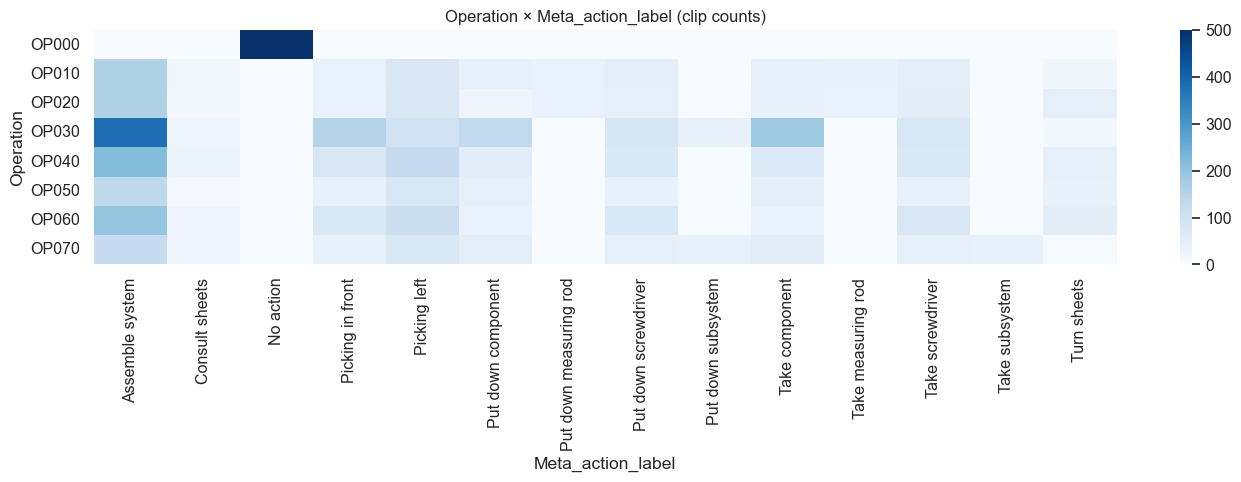

In [19]:
# --- Mean duration by meta-action ---
if "Meta_action_label" in df.columns and "Duration_sec" in df.columns:
    g_meta = (
        df.groupby("Meta_action_label", observed=True)
        .agg(mean_duration_s=("Duration_sec", "mean"), n_clips=("Duration_sec", "count"))
        .sort_values("n_clips", ascending=False)
    )
    display(g_meta.round(3))

# --- Clips per session file ---
if "File" in df.columns:
    g_file = df.groupby("File").size().sort_values(ascending=False).reset_index(name="n_clips")
    display(g_file.head(15))

# --- Cross-tab: Operation × Meta_action_label (counts) ---
if "Operation" in df.columns and "Meta_action_label" in df.columns:
    ct = pd.crosstab(df["Operation"], df["Meta_action_label"])
    plt.figure(figsize=(14, 5))
    sns.heatmap(ct, cmap="Blues", annot=False)
    plt.title("Operation × Meta_action_label (clip counts)")
    plt.tight_layout()
    plt.show()


In [20]:
# --- Optional: compare row counts Online vs Segmented ---
if df_online is not None:
    compare = pd.DataFrame(
        {
            "dataset": ["Segmented", "Online"],
            "rows": [len(df), len(df_online)],
        }
    )
    display(compare)
    print("Note: Online/InHARD.csv typically excludes 'No action' segments — see analysis.md.")


,dataset,rows
0,Segmented,5303
1,Online,4803


Note: Online/InHARD.csv typically excludes 'No action' segments — see analysis.md.


## 9. Summary of findings (placeholder)

_Use this section after you run the notebook to capture **stakeholder-ready** conclusions._

| Topic | Observation | Implication for modeling |
|-------|-------------|---------------------------|
| Class balance | e.g. dominant meta-actions | Weighted loss / sampling |
| Durations | tail behavior / outliers | Sequence length padding strategy |
| Operations | spread across OP0xx | Operation-conditional heads or grouping |
| Data quality | missing / duplicates | Cleaning rules |

**Next steps (examples):** stratified train/val by `File` (session), merge taxonomy from `rsc/Action-Meta-action-list.xlsx`, add media-level EDA (frame decoding, BVH joint ranges).

---
*Template generated for course/project EDA — extend cells as needed.*
